# Unified Framework Demo — C-TFT

This notebook demonstrates the full C-TFT framework on 10 exemplar samples (5 O, 5 NO):
1. Load trained R-TFT and L-TFT models
2. Generate predictions (R-TFT: regression + classification, L-TFT: regression only)
3. Bayesian MCMC sensor fusion → C-TFT posterior predictions
4. Denormalisation and forecast visualisation
5. Interpretability analysis (variable importance + attention weights)

**Requirements:** See `README.md` for setup instructions.

---
## 1. Setup

In [3]:
import sys
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.dates as mdates
from matplotlib.lines import Line2D

sys.path.insert(0, 'source')

plt.rc('font', family='Times New Roman')

print("✓ Imports done")

✓ Imports done


In [4]:
# =============================================================================
# Configuration
# =============================================================================
MODEL_DIR = 'models'
DATA_DIR = 'data'
FIGURES_DIR = 'figures'
os.makedirs(FIGURES_DIR, exist_ok=True)

STYLE = {
    'fig_size': (8, 6),
    'font_label': 20,
    'font_tick': 16,
    'font_legend': 14,
    'linewidth': 2.5,
    'spine_width': 1.1,
}

def style_axis(ax, xlabel=None, ylabel=None):
    if xlabel:
        ax.set_xlabel(xlabel, fontsize=STYLE['font_label'], labelpad=8)
    if ylabel:
        ax.set_ylabel(ylabel, fontsize=STYLE['font_label'])
    ax.grid(True, color='gainsboro', linestyle=':', linewidth=1, alpha=0.6)
    ax.tick_params(axis='both', which='major', direction='out', length=5,
                   width=STYLE['spine_width'], labelsize=STYLE['font_tick'])
    for spine in ax.spines.values():
        spine.set_linewidth(STYLE['spine_width'])

print("✓ Configuration set")

✓ Configuration set


---
## 2. Load Exemplar Data

In [6]:
with open(os.path.join(DATA_DIR, 'exemplar_samples.pkl'), 'rb') as f:
    exemplar = pickle.load(f)

X_main = exemplar['main']['inputs']
X_temporal = exemplar['temporal']['inputs']
Y_reg = exemplar['outputs']['regression']
Y_class = exemplar['outputs']['classification']
labels = exemplar['metadata']['labels']
dma_ids = exemplar['metadata']['dma_ids']
scaler_output = exemplar['scaler']

print("✓ Exemplar data loaded")
print(f"  Samples: {len(labels)} ({labels.count('O')} O, {labels.count('NO')} NO)")
for i, (lbl, dma) in enumerate(zip(labels, dma_ids)):
    print(f"  [{i}] {lbl} — DMA {dma}")

✓ Exemplar data loaded
  Samples: 10 (5 O, 5 NO)
  [0] O — DMA 1778
  [1] O — DMA 1773
  [2] O — DMA 166
  [3] O — DMA 203
  [4] O — DMA 761
  [5] NO — DMA 463
  [6] NO — DMA 377
  [7] NO — DMA 1041
  [8] NO — DMA 591
  [9] NO — DMA 570


C:\Users\marti\anaconda3\envs\water-flow\lib\site-packages\sklearn\base.py:376: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.4.2 when using version 1.5.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


---
## 3. Load Trained Models

In [8]:
from tft import TemporalFusionTransformer
from tft_losses import get_custom_losses_and_metrics

with open(os.path.join(MODEL_DIR, 'tft_config.pkl'), 'rb') as f:
    config_rtft = pickle.load(f)

r_tft = TemporalFusionTransformer(**{
    k: config_rtft[k] for k in [
        'input_spec', 'target_spec', 'd_model', 'att_heads',
        'lookback', 'lookforward', 'dropout_rate'
    ]
})
r_tft.build_model()
r_tft.model.load_weights(os.path.join(MODEL_DIR, 'tft_weights.h5'))

print(f"✓ R-TFT loaded ({r_tft.model.count_params():,} parameters)")

✓ R-TFT loaded (875,586 parameters)


In [9]:
from tft_temporal import TemporalFusionTransformerTemporal
from tft_losses_temporal import get_custom_losses_and_metrics as get_temporal_losses

with open(os.path.join(MODEL_DIR, 'tft_temporal_config.pkl'), 'rb') as f:
    config_ltft = pickle.load(f)

l_tft = TemporalFusionTransformerTemporal(**{
    k: config_ltft[k] for k in [
        'input_spec', 'target_spec', 'd_model', 'att_heads',
        'lookback', 'lookforward', 'dropout_rate'
    ]
})
l_tft.build_model()
l_tft.model.load_weights(os.path.join(MODEL_DIR, 'tft_temporal_weights.h5'))

print(f"✓ L-TFT loaded ({l_tft.model.count_params():,} parameters)")

✓ L-TFT loaded (6,451,969 parameters)


---
## 4. Generate Predictions

In [13]:
# R-TFT predictions (regression + classification)
y_pred_rtft = r_tft.model.predict(X_main)
pred_reg_rtft = y_pred_rtft['regression']
pred_class_rtft = y_pred_rtft['classification']

pred_5th_main = pred_reg_rtft[:, :, 0]
pred_50th_main = pred_reg_rtft[:, :, 1]
pred_95th_main = pred_reg_rtft[:, :, 2]

# L-TFT predictions (regression only)
y_pred_ltft = l_tft.model.predict(X_temporal)
pred_reg_ltft = y_pred_ltft['regression'] if isinstance(y_pred_ltft, dict) else y_pred_ltft

pred_5th_temporal = pred_reg_ltft[:, :, 0]
pred_50th_temporal = pred_reg_ltft[:, :, 1]
pred_95th_temporal = pred_reg_ltft[:, :, 2]

print("✓ Predictions generated")
print(f"  R-TFT regression: {pred_reg_rtft.shape}")
print(f"  R-TFT classification: {pred_class_rtft.shape}")
print(f"  L-TFT regression: {pred_reg_ltft.shape}")
for i, (lbl, prob) in enumerate(zip(labels, pred_class_rtft.ravel())):
    print(f"  [{i}] {lbl} — P(leak) = {prob:.4f}")

1/1 [==============================] - 4s 4s/step
✓ Predictions generated
  R-TFT regression: (10, 96, 3)
  R-TFT classification: (10, 1)
  L-TFT regression: (10, 96, 3)
  [0] O — P(leak) = 0.9641
  [1] O — P(leak) = 0.8621
  [2] O — P(leak) = 0.9863
  [3] O — P(leak) = 0.9959
  [4] O — P(leak) = 0.9755
  [5] NO — P(leak) = 0.2175
  [6] NO — P(leak) = 0.0442
  [7] NO — P(leak) = 0.0175
  [8] NO — P(leak) = 0.0874
  [9] NO — P(leak) = 0.0179


---
## 5. Bayesian MCMC Sensor Fusion (C-TFT)

Fuses R-TFT and L-TFT predictions via NUTS MCMC with Student-t distributions.
With 10 samples × 96 timesteps = 960 fusion operations, this typically completes in a few minutes.

In [16]:
import mcmc_fusion

combined_pred, lower_90, upper_90, rhat_vals, ess_vals = mcmc_fusion.combine_predictions(
    pred_5th_main, pred_95th_main, pred_50th_main,
    pred_5th_temporal, pred_95th_temporal, pred_50th_temporal
)

print("✓ C-TFT Bayesian fusion complete")
print(f"  Combined predictions shape: {combined_pred.shape}")
print(f"  R-hat — mean: {np.mean(rhat_vals):.4f}, max: {np.max(rhat_vals):.4f}")
print(f"  ESS bulk — mean: {np.mean(ess_vals):.0f}, min: {np.min(ess_vals):.0f}")

WARNING (pytensor.configdefaults): g++ not available, if using conda: `conda install m2w64-toolchain`
WARNING (pytensor.configdefaults): g++ not detected!  PyTensor will be unable to compile C-implementations and will default to Python. Performance may be severely degraded. To remove this warning, set PyTensor flags cxx to an empty string.
WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.
MCMC Fusion: 100%|██████████| 960/960 [11:15<00:00,  1.42it/s]


✓ C-TFT Bayesian fusion complete
  Combined predictions shape: (10, 96)
  R-hat — mean: 1.0003, max: 1.0100
  ESS bulk — mean: 1554, min: 1056


---
## 6. Denormalisation

In [18]:
def denormalize(sequences, scaler):
    mask = sequences != -1
    result = np.full_like(sequences, fill_value=-1, dtype=float)
    result[mask] = scaler.inverse_transform(sequences[mask].reshape(-1, 1)).flatten()
    return result

y_true_d = denormalize(Y_reg[:, :, 0], scaler_output)

c_tft_pred_d = denormalize(combined_pred, scaler_output)
c_tft_lower_d = denormalize(lower_90, scaler_output)
c_tft_upper_d = denormalize(upper_90, scaler_output)

r_tft_pred_d = denormalize(pred_50th_main, scaler_output)

print("✓ Denormalisation complete")

✓ Denormalisation complete


---
## 7. Forecast Visualisation

C-TFT posterior predictions with 90% credible intervals for all 10 exemplar samples.

In [20]:
def index_of_agreement(y_true, y_pred):
    numerator = np.sum((y_true - y_pred) ** 2)
    denominator = np.sum((np.abs(y_pred - np.mean(y_true)) + np.abs(y_true - np.mean(y_true))) ** 2)
    return 1 - (numerator / denominator) if denominator != 0 else np.nan

# Load observed scaler for input denormalisation
with open(os.path.join(DATA_DIR, 'scalers.pkl'), 'rb') as f:
    all_scalers = pickle.load(f)
scaler_observed = all_scalers['observed_main']

def plot_exemplar(idx, hist_trim=192):
    """Plot C-TFT forecast with input flow for a single exemplar sample."""
    true = y_true_d[idx]
    pred = c_tft_pred_d[idx]
    lower = c_tft_lower_d[idx]
    upper = c_tft_upper_d[idx]
    mask = true != -1
    
    # Input flow (trimmed)
    inp = X_main['past_observed_real_0'][idx].flatten()
    inp_d = denormalize(inp.reshape(1, -1), scaler_observed).flatten()
    inp_trimmed = inp_d[-hist_trim:]
    
    lbl = labels[idx]
    true_color = 'tomato' if lbl == 'O' else 'cornflowerblue'
    ia = index_of_agreement(true[mask], pred[mask])
    rmse = np.sqrt(np.mean((true[mask] - pred[mask]) ** 2))
    within = (true[mask] >= lower[mask]) & (true[mask] <= upper[mask])
    picp = np.mean(within)
    width = upper[mask] - lower[mask]
    r = np.max(true[mask]) - np.min(true[mask])
    pinaw = np.mean(width / r) if r > 0 else np.nan
    p_leak = pred_class_rtft.ravel()[idx]
    
    fig, ax = plt.subplots(figsize=STYLE['fig_size'])
    
    n_inp = len(inp_trimmed)
    n_out = int(np.sum(mask))
    
    ax.plot(range(n_inp), inp_trimmed, color='grey', lw=STYLE['linewidth'])
    ax.plot(range(n_inp, n_inp + n_out), true[mask], color=true_color, lw=STYLE['linewidth'])
    ax.plot(range(n_inp, n_inp + n_out), pred[mask], color='#2E8B57', lw=STYLE['linewidth'])
    ax.fill_between(range(n_inp, n_inp + n_out), lower[mask], upper[mask],
                    color='#66CC66', alpha=0.2)
    
    # P(leak) annotation
    ax.text(0.97, 0.95, f'P(leak) = {p_leak:.3f}', transform=ax.transAxes,
            fontsize=STYLE['font_tick'], ha='right', va='top',
            bbox=dict(boxstyle='square', facecolor='white', edgecolor='black', pad=0.3, linewidth=0.6))
    
    # Legend at top with explicit handles
    handles = [
        Line2D([], [], color='grey', lw=STYLE['linewidth']),
        Line2D([], [], color=true_color, lw=STYLE['linewidth']),
        Line2D([], [], color='#2E8B57', lw=STYLE['linewidth']),
        mpatches.Rectangle((0, 0), 1, 1, facecolor='#66CC66', alpha=0.2, edgecolor='black', linewidth=0.6),
    ]
    legend = ax.legend(
        handles=handles,
        labels=['Input', f'True ({lbl})', 'C-TFT prediction', '90% CI'],
        loc='upper center', bbox_to_anchor=(0.5, 1.12),
        fontsize=STYLE['font_legend'], frameon=True,
        ncol=4, handletextpad=0.3, columnspacing=0.4
    )
    legend.get_frame().set_edgecolor('black')
    legend.get_frame().set_linewidth(0.6)
    legend.get_frame().set_boxstyle("Square")
    
    style_axis(ax, 'Timestep (15-min intervals)', 'Flow (l/s)')
    
    max_y = max(np.max(inp_trimmed), np.max(true[mask]), np.max(upper[mask]))
    max_y = 4 * (int(max_y / 4) + 1)
    ax.set_ylim(0, max_y)
    ax.set_yticks(np.linspace(0, max_y, 5).astype(int))
    
    plt.tight_layout()
    plt.savefig(os.path.join(FIGURES_DIR, f'exemplar_{idx}_{lbl}.png'), dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"  [{idx}] {lbl} | DMA {dma_ids[idx]} | IA={ia:.3f} | RMSE={rmse:.3f} | PICP={picp:.3f} | PINAW={pinaw:.3f} | P(leak)={p_leak:.3f}")

=== O Samples ===


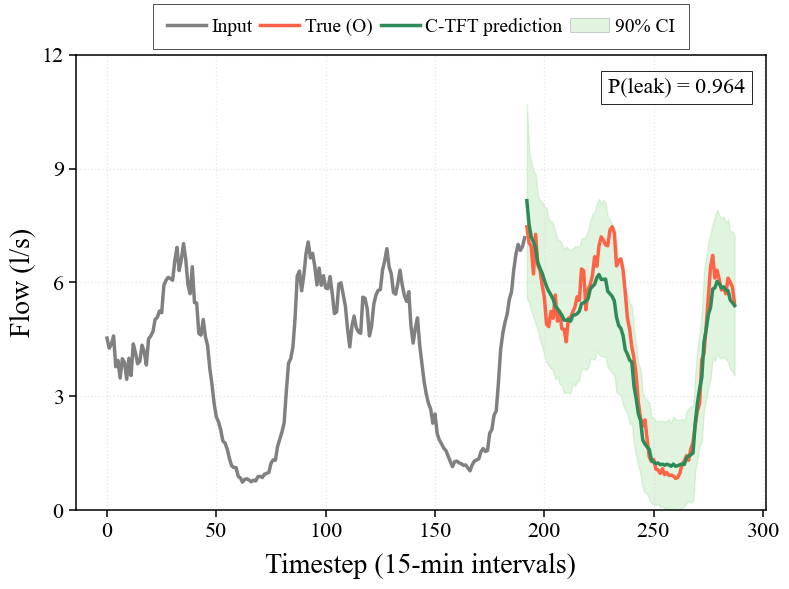

  [0] O | DMA 1778 | IA=0.974 | RMSE=0.670 | PICP=0.979 | PINAW=0.503 | P(leak)=0.964


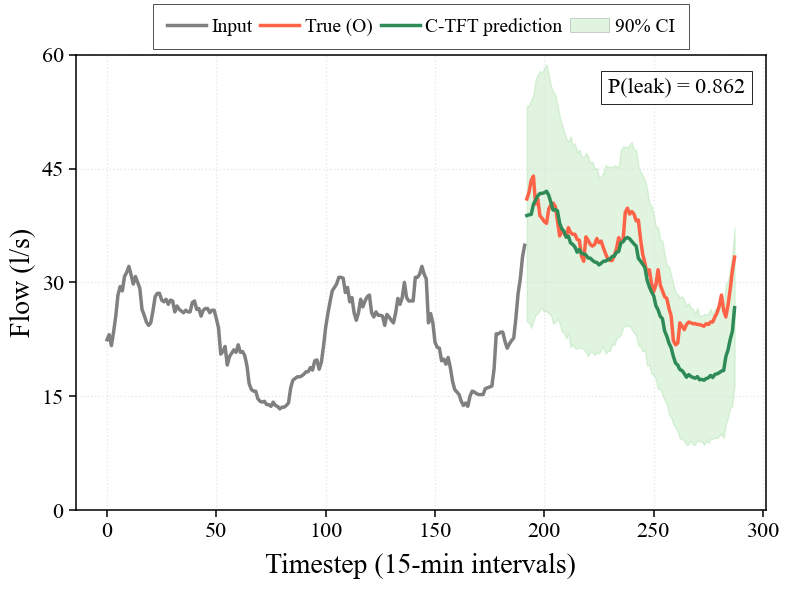

  [1] O | DMA 1773 | IA=0.908 | RMSE=4.338 | PICP=0.979 | PINAW=1.033 | P(leak)=0.862


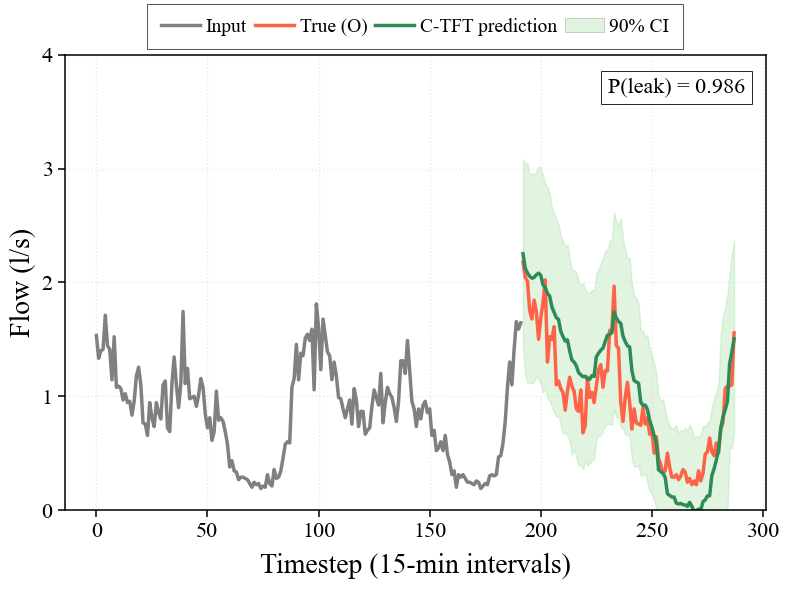

  [2] O | DMA 166 | IA=0.932 | RMSE=0.306 | PICP=1.000 | PINAW=0.772 | P(leak)=0.986


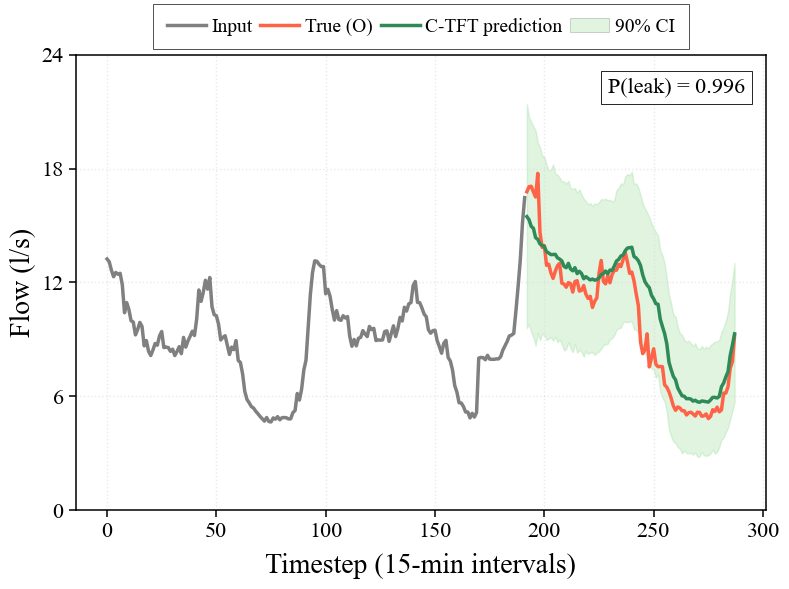

  [3] O | DMA 203 | IA=0.949 | RMSE=1.533 | PICP=0.969 | PINAW=0.586 | P(leak)=0.996


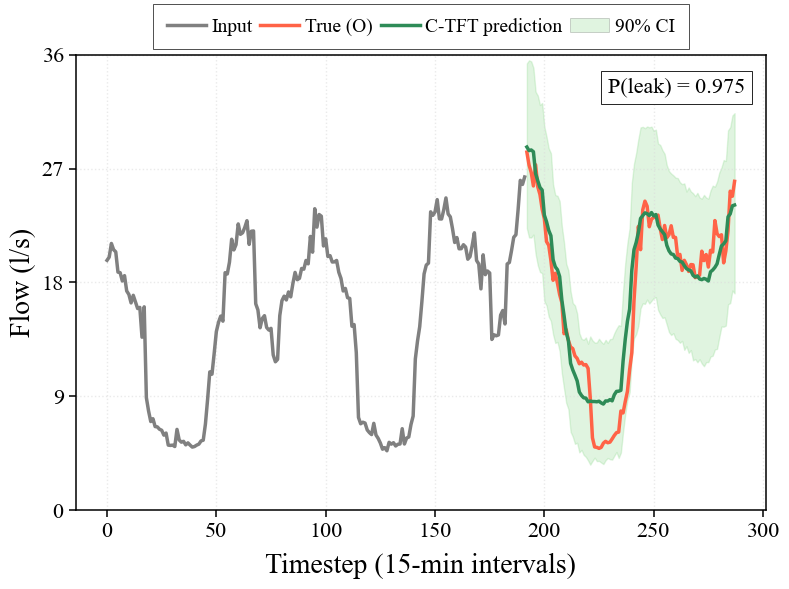

  [4] O | DMA 761 | IA=0.969 | RMSE=2.167 | PICP=1.000 | PINAW=0.521 | P(leak)=0.975

=== NO Samples ===


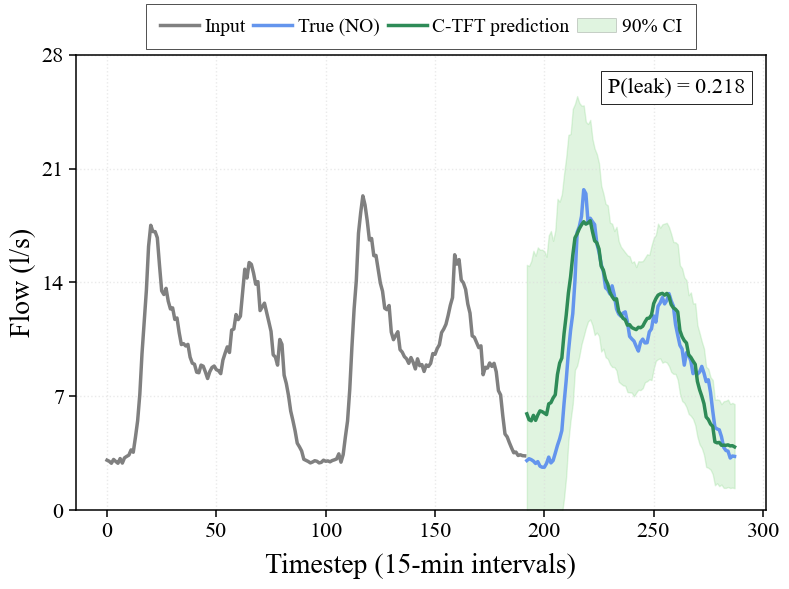

  [5] NO | DMA 463 | IA=0.953 | RMSE=1.879 | PICP=1.000 | PINAW=0.646 | P(leak)=0.218


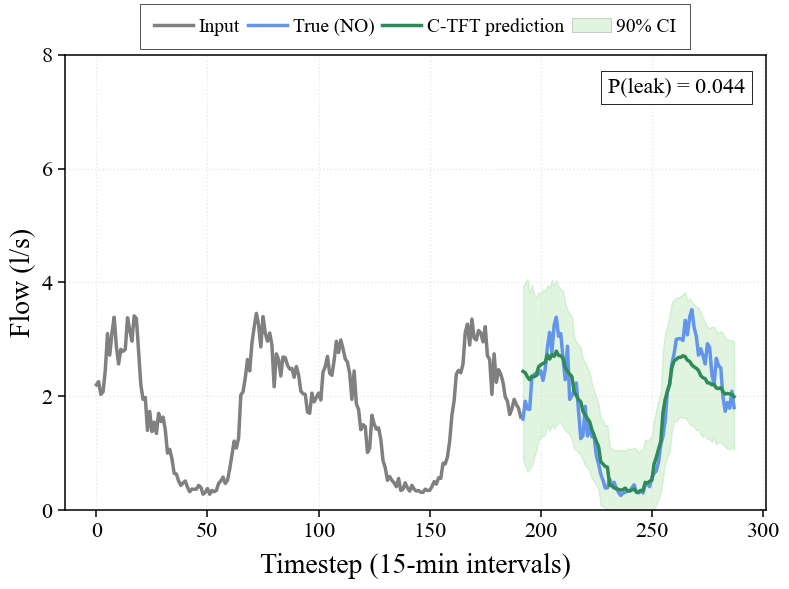

  [6] NO | DMA 377 | IA=0.967 | RMSE=0.336 | PICP=1.000 | PINAW=0.610 | P(leak)=0.044


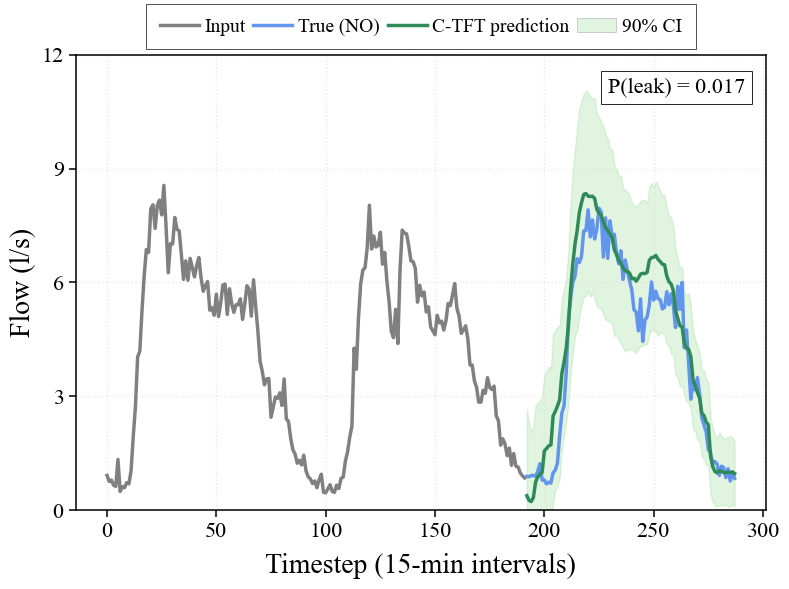

  [7] NO | DMA 1041 | IA=0.978 | RMSE=0.739 | PICP=1.000 | PINAW=0.508 | P(leak)=0.017


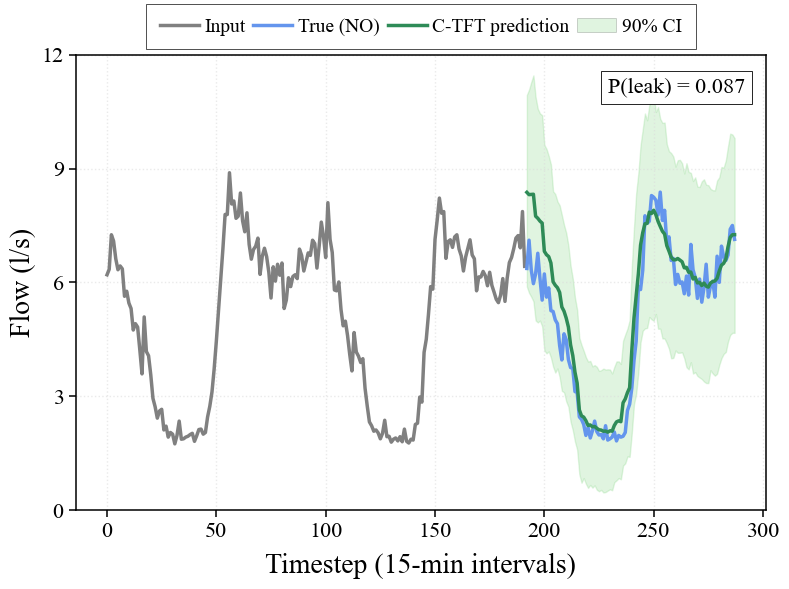

  [8] NO | DMA 591 | IA=0.966 | RMSE=0.742 | PICP=1.000 | PINAW=0.707 | P(leak)=0.087


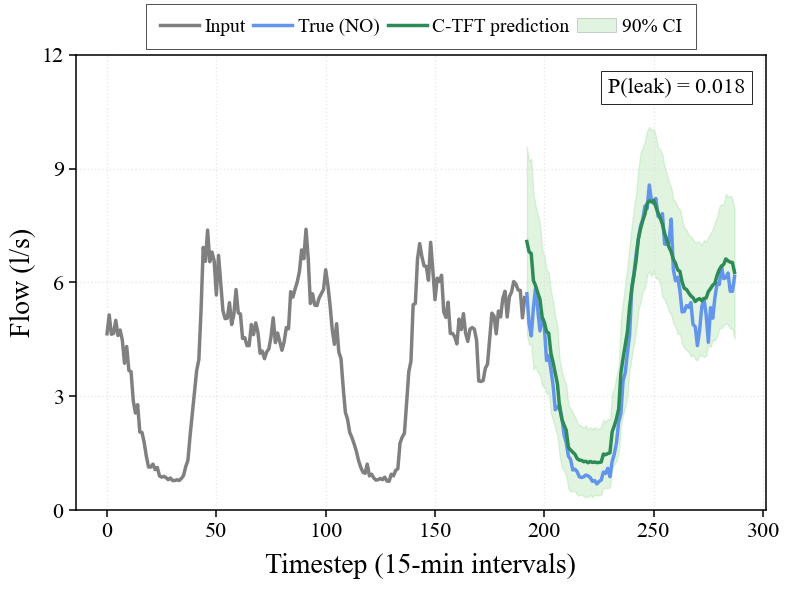

  [9] NO | DMA 570 | IA=0.983 | RMSE=0.598 | PICP=1.000 | PINAW=0.384 | P(leak)=0.018


In [21]:
# Plot all 10 exemplar samples
print("=== O Samples ===")
for i in range(5):
    plot_exemplar(i)

print("\n=== NO Samples ===")
for i in range(5, 10):
    plot_exemplar(i)

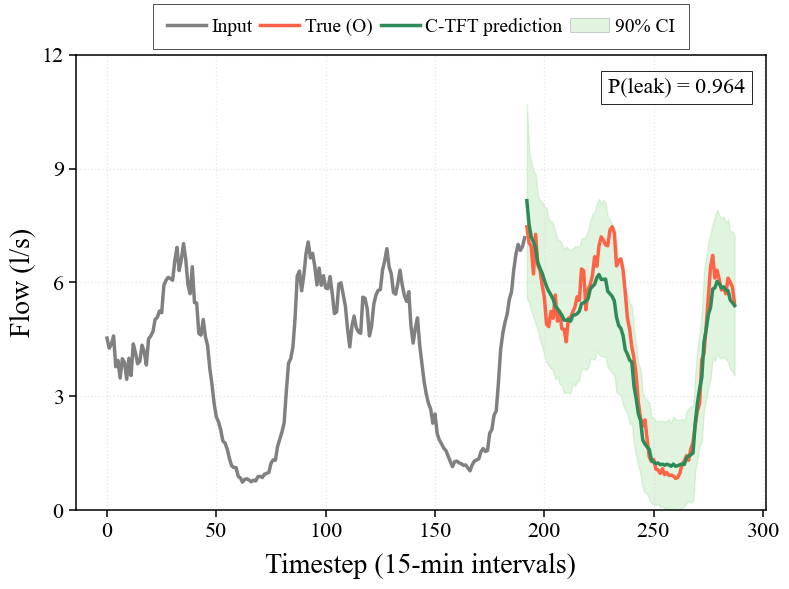

  [0] O | DMA 1778 | IA=0.974 | RMSE=0.670 | PICP=0.979 | PINAW=0.503 | P(leak)=0.964


In [22]:
# =============================================================================
# Plot a specific sample — change EXAMPLE_IDX to browse (0-9)
# =============================================================================
EXAMPLE_IDX = 0
plot_exemplar(EXAMPLE_IDX)

---
## 8. Interpretability Analysis

Variable selection weights and attention patterns from R-TFT and L-TFT.
Computed on the 10 exemplar samples.

In [24]:
import tensorflow as tf

with tf.device('/CPU:0'):
    interp_rtft = r_tft.get_interpretation_weights(X_main)
    interp_ltft = l_tft.get_interpretation_weights(X_temporal)

print("✓ Interpretation weights generated")
print(f"  R-TFT — static: {interp_rtft['static_weights'].shape}, "
      f"past: {interp_rtft['past_weights'].shape}, "
      f"future: {interp_rtft['future_weights'].shape}, "
      f"attention: {interp_rtft['attention_weights'].shape}")
print(f"  L-TFT — static: {interp_ltft['static_weights'].shape}, "
      f"past: {interp_ltft['past_weights'].shape}, "
      f"future: {interp_ltft['future_weights'].shape}, "
      f"attention: {interp_ltft['attention_weights'].shape}")

1/1 [==============================] - 4s 4s/step
✓ Interpretation weights generated
  R-TFT — static: (10, 2), past: (10, 672, 6), future: (10, 96, 5), attention: (10, 768, 768)
  L-TFT — static: (10, 2), past: (10, 672, 6), future: (10, 96, 5), attention: (10, 768, 768)


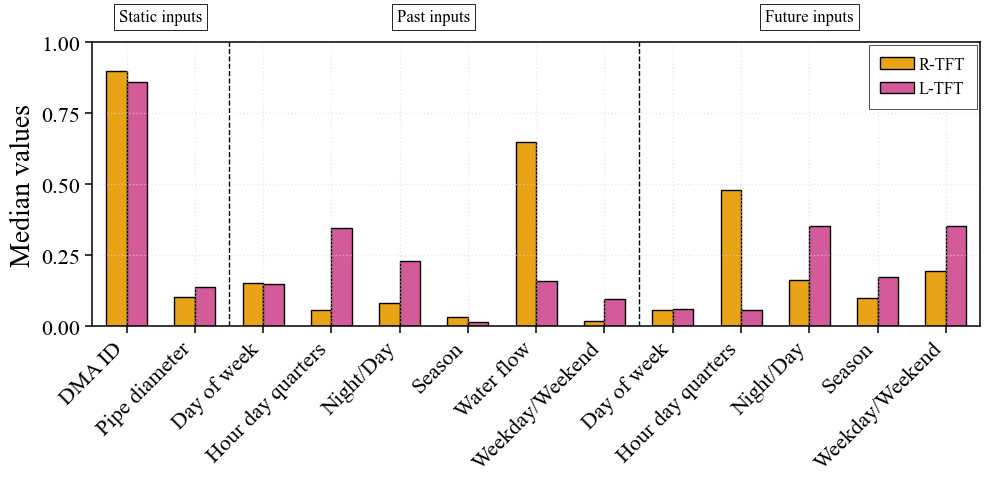

In [25]:
# Variable Importance
KNOWN_INPUTS = ['Weekday/Weekend', 'Hour day quarters', 'Day of week', 'Night/Day', 'Season']
OBSERVED_INPUTS = ['Water flow']
STATIC_NAMES = ['DMA ID', 'Pipe diameter']

def aggregate_weights(weights, variable_names):
    if 'static_context' in variable_names:
        idx = variable_names.index('static_context')
        weights = np.delete(weights, idx, axis=-1)
        variable_names = [v for v in variable_names if v != 'static_context']
    aggregated = np.mean(weights, axis=tuple(range(weights.ndim - 1)))
    median_vals = np.percentile(weights, 50, axis=tuple(range(weights.ndim - 1)))
    agg_sum = np.sum(aggregated)
    med_sum = np.sum(median_vals)
    if agg_sum != 0: aggregated /= agg_sum
    if med_sum != 0: median_vals /= med_sum
    return pd.DataFrame({'Variable': variable_names, 'Median': np.round(median_vals, 3),
                         'Mean': np.round(aggregated, 3)}).set_index('Variable')

def compute_model_weights(interp_weights):
    static_df = aggregate_weights(interp_weights['static_weights'], STATIC_NAMES.copy())
    past_vars = OBSERVED_INPUTS + KNOWN_INPUTS
    pw = interp_weights['past_weights']
    if len(past_vars) < pw.shape[-1]:
        pw = pw[..., :len(past_vars)]
    past_df = aggregate_weights(pw, past_vars.copy())
    future_vars = KNOWN_INPUTS.copy()
    fw = interp_weights['future_weights']
    if len(future_vars) < fw.shape[-1]:
        fw = fw[..., :len(future_vars)]
    future_df = aggregate_weights(fw, future_vars)
    return pd.concat([static_df, past_df, future_df], keys=['Static', 'Past Observed', 'Future Observed'])

weights_rtft = compute_model_weights(interp_rtft)
weights_ltft = compute_model_weights(interp_ltft)

# Bar chart
df_r = weights_rtft.drop(index=[('Past Observed', 'static_context'),
                                 ('Future Observed', 'static_context')], errors='ignore').reset_index()
df_l = weights_ltft.drop(index=[('Past Observed', 'static_context'),
                                 ('Future Observed', 'static_context')], errors='ignore').reset_index()
df_r.columns = ['Category', 'Variable', 'Median_R', 'Mean_R']
df_l.columns = ['Category', 'Variable', 'Median_L', 'Mean_L']
plot_df = pd.merge(df_r[['Category', 'Variable', 'Median_R']],
                   df_l[['Category', 'Variable', 'Median_L']],
                   on=['Category', 'Variable'], how='outer', sort=False).drop_duplicates(subset=['Category', 'Variable'])
ordered_df = pd.concat([
    plot_df[plot_df['Category'] == 'Static'],
    plot_df[plot_df['Category'] == 'Past Observed'],
    plot_df[plot_df['Category'] == 'Future Observed']
]).reset_index(drop=True)

n_vars = len(ordered_df)
bar_width = 0.3
index = np.arange(n_vars)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(index - bar_width/2, ordered_df['Median_R'], bar_width, color='#E8A317', edgecolor='black')
ax.bar(index + bar_width/2, ordered_df['Median_L'], bar_width, color='#D45B9A', edgecolor='black')
ax.set_xticks(index)
ax.set_xticklabels(ordered_df['Variable'], fontsize=12, rotation=45, ha='right')
ax.set_ylim(0, 1.0)
ax.set_yticks([0, 0.25, 0.50, 0.75, 1.0])

for cat, label in [('Static', 'Static inputs'), ('Past Observed', 'Past inputs'), ('Future Observed', 'Future inputs')]:
    cat_idx = ordered_df[ordered_df['Category'] == cat].index
    if len(cat_idx) > 0:
        center = (cat_idx[0] + cat_idx[-1]) / 2
        ax.text(center, 1.06, label, ha='center', va='bottom', fontsize=12,
                transform=ax.get_xaxis_transform(),
                bbox=dict(boxstyle='square,pad=0.3', edgecolor='black', facecolor='white', linewidth=0.6))
        if cat_idx[-1] < n_vars - 1:
            ax.axvline(x=cat_idx[-1] + 0.5, color='black', linestyle='--', linewidth=1)

# Legend at top with explicit handles
handles_vi = [
    mpatches.Rectangle((0, 0), 1, 1, facecolor='#E8A317', edgecolor='black'),
    mpatches.Rectangle((0, 0), 1, 1, facecolor='#D45B9A', edgecolor='black'),
]
legend = ax.legend(
    handles=handles_vi, labels=['R-TFT', 'L-TFT'],
    loc='upper right', fontsize=12, frameon=True,
    ncol=1, handletextpad=0.3
)
legend.get_frame().set_edgecolor('black')
legend.get_frame().set_linewidth(0.6)
legend.get_frame().set_boxstyle("Square")

style_axis(ax, ylabel='Median values')
ax.set_xlim(-0.5, n_vars - 0.5)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'variable_importance.png'), dpi=300, bbox_inches='tight')
plt.show()

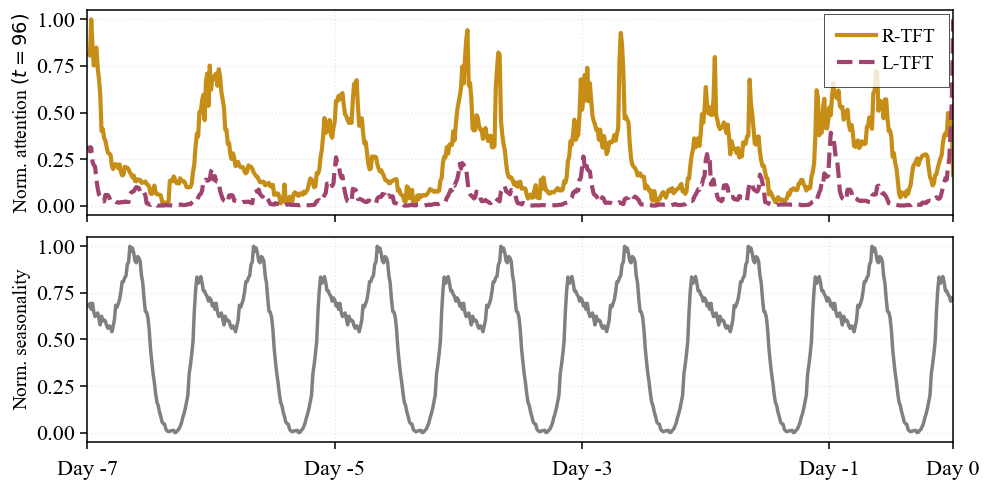

In [26]:
# Attention Weights
from statsmodels.tsa.seasonal import seasonal_decompose

def process_attention_weights(attention_weights, horizon=672):
    if attention_weights.ndim == 4:
        attention_weights = np.squeeze(attention_weights, axis=0)
    past_weights = attention_weights[:, -96:, :horizon]
    return np.mean(past_weights, axis=0)

def normalize_series(series):
    return (series - np.min(series)) / (np.max(series) - np.min(series))

att_rtft = process_attention_weights(interp_rtft['attention_weights'], horizon=672)
att_ltft = process_attention_weights(interp_ltft['attention_weights'], horizon=672)

norm_rtft = normalize_series(att_rtft[95, ::-1])
norm_ltft = normalize_series(att_ltft[95, ::-1])

# Seasonality from exemplar water flow
sample_flow_d = denormalize(
    X_main['past_observed_real_0'][0].flatten().reshape(1, -1), scaler_observed
).flatten()
decomposition = seasonal_decompose(sample_flow_d, period=96, model='additive')
norm_seasonality = normalize_series(decomposition.seasonal[:672])

horizon = 672
x_axis = -np.arange(horizon)[::-1]
xticks = [-672, -480, -288, -96, 0]
xticklabels = ['Day -7', 'Day -5', 'Day -3', 'Day -1', 'Day 0']

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 5))

ax1.plot(x_axis, norm_rtft, color='#C68E17', linewidth=3.0, linestyle='-')
ax1.plot(x_axis, norm_ltft, color='#A0436E', linewidth=3.0, linestyle='--')
ax1.set_ylabel(r'Norm. attention $(t=96)$', fontsize=14)
ax1.set_xlim(-horizon, 0)
ax1.set_xticks(xticks)
ax1.set_xticklabels([])
ax1.set_yticks([0, 0.25, 0.5, 0.75, 1.0])
style_axis(ax1)

# Legend with explicit handles
handles_att = [
    Line2D([], [], color='#C68E17', linewidth=3.0, linestyle='-'),
    Line2D([], [], color='#A0436E', linewidth=3.0, linestyle='--'),
]
legend = ax1.legend(
    handles=handles_att, labels=['R-TFT', 'L-TFT'],
    loc='upper right', fontsize=STYLE['font_legend'], frameon=True,
    ncol=1, handletextpad=0.3
)
legend.get_frame().set_edgecolor('black')
legend.get_frame().set_linewidth(0.6)
legend.get_frame().set_boxstyle("Square")

ax2.plot(x_axis, norm_seasonality, color='gray', linewidth=2.5)
ax2.set_ylabel(r'Norm. seasonality', fontsize=14)
ax2.set_xlim(-horizon, 0)
ax2.set_xticks(xticks)
ax2.set_xticklabels(xticklabels, fontsize=STYLE['font_tick'])
ax2.tick_params(axis='x', which='major', pad=8)
ax2.set_yticks([0, 0.25, 0.5, 0.75, 1.0])
style_axis(ax2)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'attention_seasonality.png'), dpi=300, bbox_inches='tight')
plt.show()

---
## 9. Summary

In [28]:
print("=" * 60)
print("UNIFIED FRAMEWORK DEMO — COMPLETE")
print("=" * 60)

print(f"\nModels loaded: R-TFT, L-TFT")
print(f"Bayesian fusion: C-TFT (NUTS MCMC, {mcmc_fusion.DRAWS} draws, {mcmc_fusion.CHAINS} chains)")
print(f"Samples: {len(labels)} ({labels.count('O')} O, {labels.count('NO')} NO)")

print(f"\nC-TFT Performance on exemplar samples:")
for i in range(len(labels)):
    true = y_true_d[i]
    pred = c_tft_pred_d[i]
    mask = true != -1
    ia = index_of_agreement(true[mask], pred[mask])
    p_leak = pred_class_rtft.ravel()[i]
    print(f"  [{i}] {labels[i]} | DMA {dma_ids[i]} | IA={ia:.3f} | P(leak)={p_leak:.3f}")

print(f"\nFigures saved to: {FIGURES_DIR}/")

UNIFIED FRAMEWORK DEMO — COMPLETE

Models loaded: R-TFT, L-TFT
Bayesian fusion: C-TFT (NUTS MCMC, 1000 draws, 4 chains)
Samples: 10 (5 O, 5 NO)

C-TFT Performance on exemplar samples:
  [0] O | DMA 1778 | IA=0.974 | P(leak)=0.964
  [1] O | DMA 1773 | IA=0.908 | P(leak)=0.862
  [2] O | DMA 166 | IA=0.932 | P(leak)=0.986
  [3] O | DMA 203 | IA=0.949 | P(leak)=0.996
  [4] O | DMA 761 | IA=0.969 | P(leak)=0.975
  [5] NO | DMA 463 | IA=0.953 | P(leak)=0.218
  [6] NO | DMA 377 | IA=0.967 | P(leak)=0.044
  [7] NO | DMA 1041 | IA=0.978 | P(leak)=0.017
  [8] NO | DMA 591 | IA=0.966 | P(leak)=0.087
  [9] NO | DMA 570 | IA=0.983 | P(leak)=0.018

Figures saved to: figures/
